In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/rkiattisak/salaly-prediction-for-beginer/Salary Data.csv


In [2]:
import pandas as ps
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('/kaggle/input/datasets/rkiattisak/salaly-prediction-for-beginer/Salary Data.csv')

In [4]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  373 non-null    float64
 1   Gender               373 non-null    object 
 2   Education Level      373 non-null    object 
 3   Job Title            373 non-null    object 
 4   Years of Experience  373 non-null    float64
 5   Salary               373 non-null    float64
dtypes: float64(3), object(3)
memory usage: 17.7+ KB


In [6]:
df.describe()

,Age,Years of Experience,Salary
count,373.000000,373.000000,373.000000
mean,37.431635,10.030831,100577.345845
std,7.069073,6.557007,48240.013482
min,23.000000,0.000000,350.000000
25%,31.000000,4.000000,55000.000000
50%,36.000000,9.000000,95000.000000
75%,44.000000,15.000000,140000.000000
max,53.000000,25.000000,250000.000000


In [7]:
df.isnull().sum()

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    2
Salary                 2
dtype: int64

In [8]:
df['Years of Experience'] = df['Years of Experience'].fillna(
    df['Years of Experience'].mean()
)

In [9]:
df['Salary'] = df['Salary'].fillna(
    df['Salary'].mean()
)

Text(0, 0.5, 'Salary')

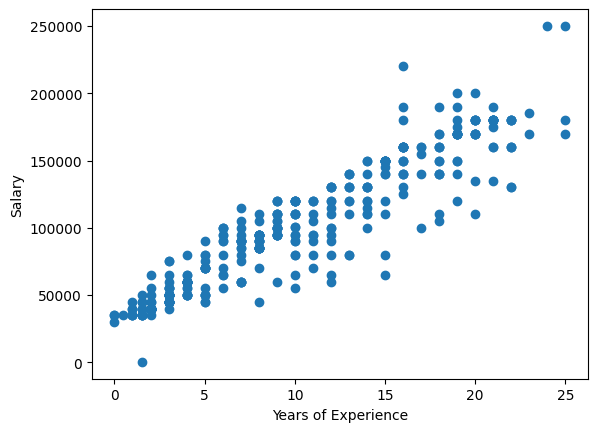

In [10]:

plt.scatter(df['Years of Experience'],df['Salary'])
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

In [11]:
X = df[['Years of Experience']]   
y = df['Salary']

In [12]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [13]:
X_train

,Years of Experience
193,7.0
75,10.0
84,2.0
363,5.0
16,7.0
...,...
71,11.0
106,3.0
270,16.0
348,1.0


In [14]:
y_train

193     95000.0
75      95000.0
84      40000.0
363     70000.0
16      90000.0
         ...   
71      70000.0
106     50000.0
270    150000.0
348     35000.0
102    150000.0
Name: Salary, Length: 300, dtype: float64

# Simple linear Regression

In [15]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [16]:
lr.fit(X_train,y_train)

LinearRegression()

Text(0, 0.5, 'Salary')

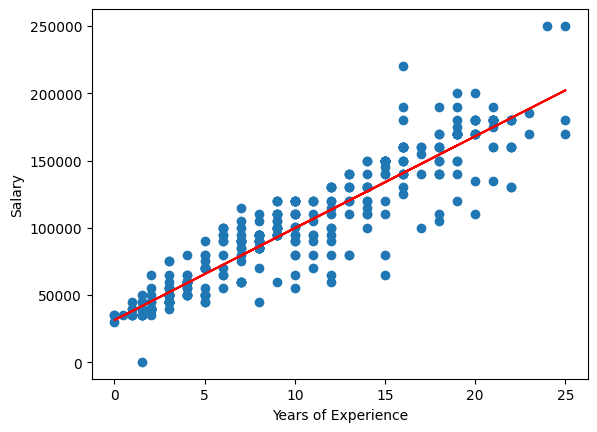

In [17]:
plt.scatter(df['Years of Experience'],df['Salary'])
plt.plot(X_train,lr.predict(X_train),color = 'red')
plt.xlabel("Years of Experience")
plt.ylabel("Salary")

In [18]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score

In [19]:
y_pred = lr.predict(X_test)
y_pred

array([154355.22616873,  99726.43447057, 140698.02824419,  72412.03862149,
       147526.62720646, 174841.02305554, 181669.62201781,  99726.43447057,
        51926.24173467,  92897.8355083 , 120212.23135738, 174841.02305554,
        45097.6427724 ,  92897.8355083 ,  58754.84069694, 140698.02824419,
        65583.43965921,  41683.34329127,  79240.63758376,  86069.23654603,
        99726.43447057,  92897.8355083 , 140698.02824419,  65583.43965921,
        99726.43447057,  58754.84069694, 168012.42409327,  99936.96768254,
       154355.22616873, 161183.825131  ,  51926.24173467, 127040.83031965,
        51926.24173467, 133869.42928192,  79240.63758376,  34854.744329  ,
       174841.02305554,  45097.6427724 ,  45097.6427724 ,  58754.84069694,
        45097.6427724 ,  86069.23654603, 202155.41890462, 161183.825131  ,
        45097.6427724 , 140698.02824419, 106555.03343284,  45097.6427724 ,
        45097.6427724 ,  45097.6427724 ,  99726.43447057,  86069.23654603,
        86069.23654603, 1

In [20]:
print("MSE",mean_squared_error(y_test,y_pred))
print("MAE",mean_absolute_error(y_test,y_pred))
print("r2 score",r2_score(y_test,y_pred))
print("RMSC",np.sqrt(mean_squared_error(y_test,y_pred)))

MSE 254964921.79041874
MAE 12279.659887588627
r2 score 0.8947512075775289
RMSC 15967.621043549936


In [21]:
r2 = r2_score(y_test,y_pred)
1 -((1-r2)*(40-1)/(40-1-1))

0.8919815025137796

In [22]:
m = lr.coef_[0]
b = lr.intercept_

print(f"Equation of Line: Salary = {m:.2f} × (Years of Experience) + {b:.2f}")

Equation of Line: Salary = 6828.60 × (Years of Experience) + 31440.44


# Multiple LinearRegression

In [23]:
import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score

In [24]:
df.head()

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [25]:
df_encoded = pd.get_dummies(
    df,
    columns=['Gender', 'Education Level', 'Job Title'],
    drop_first=True,
    dtype=int
)

df_encoded.head()

,Age,Years of Experience,Salary,Gender_Male,Education Level_Master's,Education Level_PhD,Job Title_Accountant,Job Title_Administrative Assistant,Job Title_Business Analyst,Job Title_Business Development Manager,...,Job Title_Supply Chain Manager,Job Title_Technical Recruiter,Job Title_Technical Support Specialist,Job Title_Technical Writer,Job Title_Training Specialist,Job Title_UX Designer,Job Title_UX Researcher,Job Title_VP of Finance,Job Title_VP of Operations,Job Title_Web Developer
0,32.0,5.0,90000.0,1,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,28.0,3.0,65000.0,0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,45.0,15.0,150000.0,1,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,36.0,7.0,60000.0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,52.0,20.0,200000.0,1,1,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [26]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375 entries, 0 to 374
Columns: 179 entries, Age to Job Title_Web Developer
dtypes: float64(3), int64(176)
memory usage: 524.5 KB


In [27]:
print(df.columns)

Index(['Age', 'Gender', 'Education Level', 'Job Title', 'Years of Experience',
       'Salary'],
      dtype='object')


In [28]:
df.isnull().sum().sort_values(ascending=False).head(10)

Age                    2
Gender                 2
Education Level        2
Job Title              2
Years of Experience    0
Salary                 0
dtype: int64

In [29]:
df.fillna(df.mean(numeric_only=True), inplace=True)

In [30]:
print(df.isnull().sum().sum())

6


In [31]:
df.fillna(0, inplace=True)

In [32]:
import plotly.express as px

fig = px.scatter_3d(
    df,
    x='Age',
    y='Years of Experience',
    z='Salary'
)

fig.show()

In [33]:
X = df_encoded.drop('Salary', axis=1)
y = df_encoded['Salary']

In [34]:
print("X NaN:")
print(X.isnull().sum().sum())

print("y NaN:")
print(y.isnull().sum())

X NaN:
2
y NaN:
0


In [35]:
X = X.fillna(0)

In [36]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [37]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [38]:
lr.fit(X_train,y_train)

LinearRegression()

In [39]:
y_pred = lr.predict(X_test)

In [40]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("MSE:", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 35917.436303624716
MSE: 3070890080.132286
RMSE: 55415.61224178874
R2 Score: -0.2676546653023324


In [41]:
coeff_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr.coef_
})

coeff_df.sort_values(by='Coefficient', ascending=False).head(10)

,Feature,Coefficient
4,Education Level_PhD,1.248074e+04
3,Education Level_Master's,2.526180e+03
0,Age,2.268073e+03
1,Years of Experience,1.417499e+03
2,Gender_Male,1.015037e+03
19,Job Title_Customer Success Manager,1.404260e-09
46,Job Title_Human Resources Director,1.259224e-09
170,Job Title_Technical Support Specialist,3.002469e-10
174,Job Title_UX Researcher,2.255547e-10
158,Job Title_Senior Training Specialist,1.145963e-10


In [42]:
import numpy as np
import pandas as pd

x = np.linspace(df['Age'].min(), df['Age'].max(), 10)
y = np.linspace(df['Years of Experience'].min(), df['Years of Experience'].max(), 10)

xGrid, yGrid = np.meshgrid(x, y)

# Base dataframe
X_surface = pd.DataFrame({
    'Age': xGrid.ravel(),
    'Years of Experience': yGrid.ravel()
})

# Missing columns ek saath add karo
missing_cols = [col for col in X.columns if col not in X_surface.columns]

dummy_df = pd.DataFrame(
    0,
    index=X_surface.index,
    columns=missing_cols
)

X_surface = pd.concat([X_surface, dummy_df], axis=1)

# Same order as training data
X_surface = X_surface[X.columns]

# Prediction
z_final = lr.predict(X_surface)

z = z_final.reshape(10, 10)

print(z.shape)

(10, 10)


In [43]:
import plotly.graph_objects as go

fig = go.Figure(data=[go.Surface(
    x=xGrid,
    y=yGrid,
    z=z
)])

fig.update_layout(
    scene=dict(
        xaxis_title='Age',
        yaxis_title='Years of Experience',
        zaxis_title='Salary'
    )
)

fig.show()